In [1]:
from pylab import *

### Exercise 7.3
Visualization of SIR model equilibrium points

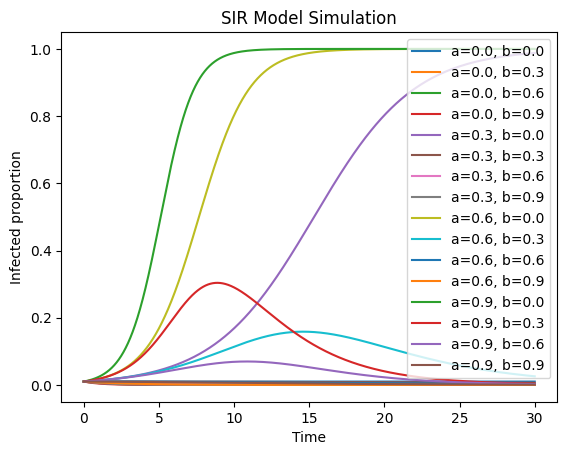

In [4]:
Dt = 0.001

def initialize():
    global s, i, r, sresult, iresult, rresult, t, timestamp
    s = 0.99
    i = 0.01
    r = 0.0
    sresult = [s]
    iresult = [i]
    rresult = [r]
    t = 0.
    timestamp = [t]

def observe():
    global s, i, r, sresult, iresult, rresult, t, timestamp
    sresult.append(s)
    iresult.append(i)
    rresult.append(r)
    timestamp.append(t)

def update(a, b):
    global s, i, r, t, sresult, iresult, rresult, timestamp
    nexts = s - (a * s * i) * Dt
    nexti = i + (a * s * i - b * i) * Dt
    nextr = r + (b * i) * Dt
    s, i, r = nexts, nexti, nextr
    t += Dt

# sweep parameters
for a in np.arange(0.0, 1.0, 0.3):
    for b in np.arange(0.0, 1.0, 0.3):
        # 1) reset state & histories
        initialize()
        # 2) run until t_final
        while t < 30.:
            update(a, b)
            observe()
        # 3) now you have the full history for this (a,b): plot or store
        plt.plot(timestamp, iresult, label=f'a={a:.1f}, b={b:.1f}')
plt.xlabel('Time')
plt.ylabel('Infected proportion')
plt.title('SIR Model Simulation')
plt.legend()
plt.show()

### Exercise 7.4
Draw a phase space of the motion of a simple pendulum

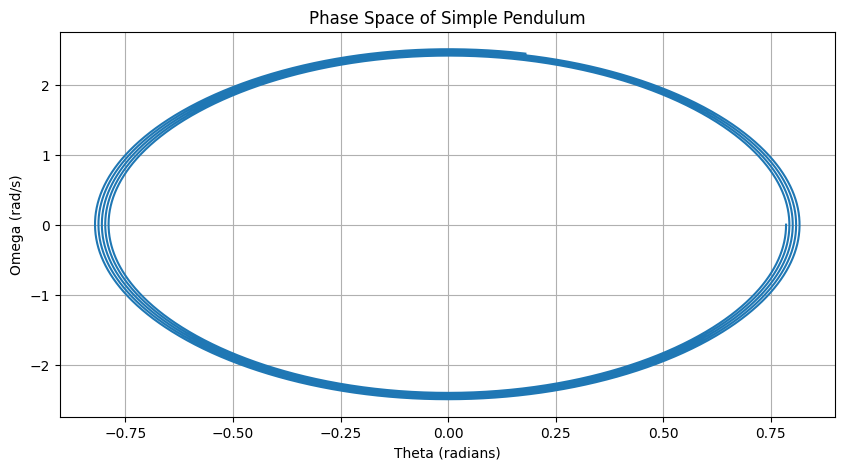

In [6]:
g = 9.81  # gravitational acceleration
l = 1.0  # length of the pendulum
Dt = 0.001  # time step

def initialize():
    global theta, omega, thetahistory, omegahistory, t, timestamp
    theta = np.pi / 4  # initial angle (45 degrees)
    omega = 0.0  # initial angular velocity
    thetahistory = [theta]
    omegahistory = [omega]
    t = 0.0
    timestamp = [t]

def observe():
    global theta, omega, thetahistory, omegahistory, t, timestamp
    thetahistory.append(theta)
    omegahistory.append(omega)
    timestamp.append(t)

def update():
    global theta, omega, t, thetahistory, omegahistory, timestamp
    nextomega = omega - (g / l) * np.sin(theta) * Dt
    nexttheta = theta + omega * Dt
    theta, omega = nexttheta, nextomega
    t += Dt

# run the simulation
initialize()
while t < 10.0:
    update()
    observe()

# plot the phase space
plt.figure(figsize=(10, 5))
plt.plot(thetahistory, omegahistory, label='Phase Space')
plt.xlabel('Theta (radians)')
plt.ylabel('Omega (rad/s)')
plt.title('Phase Space of Simple Pendulum')
plt.grid()
plt.show()